# Week 18 — Thursday (Jul 23): Edge Deployment

## Learning Objectives
- Understand the edge-deployment landscape: **TFLite**, **PyTorch Mobile / ExecuTorch**, **NCNN** — what each targets and why they exist
- Convert a trained model to **TorchScript** (`trace` and `script`) as a CPU-feasible proxy for "edge-ready" packaging
- Apply PyTorch's mobile optimization pass (operator fusion, dead-code elimination) and measure its real effect
- Benchmark eager-mode vs scripted vs mobile-optimized inference — model size and CPU latency — as an honest stand-in for an ARM edge benchmark
- Understand what a *full* TFLite/NCNN conversion would add beyond what we can demonstrate on this CPU-only, non-ARM machine

## Key Concepts
1. **TFLite** — Google's edge runtime; converts from TensorFlow/Keras (or ONNX via `onnx2tf`) to a `.tflite` FlatBuffer, with its own INT8 quantization and a dedicated ARM NEON/GPU-delegate kernel library
2. **PyTorch Mobile / ExecuTorch** — PyTorch's own edge runtime; consumes a **TorchScript** graph (legacy) or an ExecuTorch `.pte` program (current), stripped of the Python interpreter dependency
3. **NCNN** — Tencent's C++-only, dependency-free inference framework, built specifically for ARM mobile CPUs/GPUs; consumes ONNX via `onnx2ncnn`
4. **TorchScript** — a serializable, interpreter-free subset of PyTorch captured via `trace` (records one execution path) or `script` (compiles the actual Python control flow)
5. **Why this matters even without ARM hardware here** — the packaging step (removing the Python dependency, fusing ops) is hardware-independent and fully testable on CPU; only the final ARM-specific kernel dispatch needs the real device

In [1]:
import os
import io
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from torch.utils.mobile_optimizer import optimize_for_mobile

plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
print('Edge deployment demo — CPU stand-in for an ARM board (no ARM hardware available here)')

PyTorch 2.12.0+cpu | Device: cpu
Edge deployment demo — CPU stand-in for an ARM board (no ARM hardware available here)


## Section 1: Baseline Model (Eager Mode)

Same `TinyCNN` design used all week, trained fresh for this notebook.

In [2]:
class TinyCNN(nn.Module):
    '''Small conv classifier: 2x (Conv-BN-ReLU-Pool) + 2x Linear. Input: (B,1,28,28).'''
    def __init__(self, num_classes=10, c1=8, c2=16, fc_hidden=64):
        super().__init__()
        self.conv1 = nn.Conv2d(1, c1, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(c1)
        self.conv2 = nn.Conv2d(c1, c2, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(c2)
        self.pool  = nn.MaxPool2d(2)
        self.fc1   = nn.Linear(c2 * 7 * 7, fc_hidden)
        self.fc2   = nn.Linear(fc_hidden, num_classes)
        self.relu  = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = x.flatten(1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)


MNIST_ROOT = '../Week_01/data'
tf = transforms.Compose([transforms.ToTensor()])
train_full = torchvision.datasets.MNIST(root=MNIST_ROOT, train=True,  download=True, transform=tf)
test_full  = torchvision.datasets.MNIST(root=MNIST_ROOT, train=False, download=True, transform=tf)
train_dl = DataLoader(Subset(train_full, list(range(4000))), batch_size=64, shuffle=True)
test_dl  = DataLoader(Subset(test_full,  list(range(1000))), batch_size=256, shuffle=False)

torch.manual_seed(42)
model = TinyCNN().to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
model.train()
for epoch in range(5):
    for x, y in train_dl:
        opt.zero_grad()
        F.cross_entropy(model(x), y).backward()
        opt.step()
model.eval()

def accuracy(m, loader=test_dl):
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            correct += (m(x).argmax(1) == y).sum().item()
            total += y.size(0)
    return correct / total

eager_acc = accuracy(model)
print(f'Eager PyTorch model | Test accuracy: {eager_acc*100:.2f}%')

Eager PyTorch model | Test accuracy: 95.60%


## Section 2: TorchScript — `trace` vs `script`

Both remove the Python interpreter dependency, but capture the model differently:
- **`torch.jit.trace`** — runs one example input through the model and records the exact
  tensor ops that fired. Fast and simple, but **silently wrong** if the model has
  data-dependent control flow (an `if` on a tensor value, a Python loop with a variable
  trip count) — the trace only captures the branch that happened to execute.
- **`torch.jit.script`** — parses the actual Python source with the TorchScript compiler,
  so control flow is preserved. Slower to get working (stricter type rules) but correct for
  dynamic models. `TinyCNN` has no data-dependent control flow, so `trace` is safe here —
  we run both anyway to compare.

In [3]:
dummy = torch.randn(1, 1, 28, 28)

traced_model = torch.jit.trace(model, dummy)
scripted_model = torch.jit.script(model)

traced_model.save('tinycnn_traced.pt')
scripted_model.save('tinycnn_scripted.pt')

traced_acc = accuracy(traced_model)
scripted_acc = accuracy(scripted_model)

def file_size_kb(path):
    return os.path.getsize(path) / 1024

print(f'Eager model state_dict size : {sum(p.numel()*p.element_size() for p in model.parameters())/1024:.1f} KB')
print(f'Traced   TorchScript (.pt)  : {file_size_kb("tinycnn_traced.pt"):.1f} KB   | accuracy {traced_acc*100:.2f}%')
print(f'Scripted TorchScript (.pt)  : {file_size_kb("tinycnn_scripted.pt"):.1f} KB   | accuracy {scripted_acc*100:.2f}%')
print(f'\nTraced graph, human-readable:')
print(str(traced_model.graph)[:600] + ' ...')

Eager model state_dict size : 203.9 KB
Traced   TorchScript (.pt)  : 226.3 KB   | accuracy 95.60%
Scripted TorchScript (.pt)  : 228.8 KB   | accuracy 95.60%

Traced graph, human-readable:
graph(%self.1 : __torch__.TinyCNN,
      %x.1 : Float(1, 1, 28, 28, strides=[784, 784, 28, 1], requires_grad=0, device=cpu)):
  %fc2 : __torch__.torch.nn.modules.linear.___torch_mangle_2.Linear = prim::GetAttr[name="fc2"](%self.1)
  %fc1 : __torch__.torch.nn.modules.linear.Linear = prim::GetAttr[name="fc1"](%self.1)
  %bn2 : __torch__.torch.nn.modules.batchnorm.___torch_mangle_1.BatchNorm2d = prim::GetAttr[name="bn2"](%self.1)
  %conv2 : __torch__.torch.nn.modules.conv.___torch_mangle_0.Conv2d = prim::GetAttr[name="conv2"](%self.1)
  %pool : __torch__.torch.nn.modules.pooling.MaxPool2d = prim: ...


## Section 3: Mobile Optimization Pass

`torch.utils.mobile_optimizer.optimize_for_mobile` runs a fixed pipeline of graph passes
designed for edge deployment: **Conv+BatchNorm fusion**, dropout removal, and packing
Linear layers for mobile-friendly memory access. This is the same family of optimization
ONNX Runtime's graph optimizer and TFLite's converter apply — the specific passes differ,
the goal (fewer ops, less memory traffic, no training-only layers) is the same.

We then save with `_save_for_lite_interpreter`, the PyTorch Mobile deployment format (note:
the Lite Interpreter is deprecated in favour of **ExecuTorch** as of recent PyTorch
releases — we use it here because it's what's installed, and the underlying optimization
concepts transfer directly).

In [4]:
mobile_model = optimize_for_mobile(traced_model)
mobile_model._save_for_lite_interpreter('tinycnn_mobile.ptl')

mobile_size = file_size_kb('tinycnn_mobile.ptl')
mobile_acc  = accuracy(mobile_model)

print(f'Mobile-optimized (.ptl)     : {mobile_size:.1f} KB   | accuracy {mobile_acc*100:.2f}%')

# ── Prove fusion actually happened: compare op-kind histograms ────────────────
from collections import Counter

def op_kinds(graph):
    return Counter(n.kind() for n in graph.nodes())

# torch.jit.trace produces a non-inlined graph (submodules are opaque prim::CallMethod
# calls), so we inline it first to see the real op-level graph before optimization.
inlined = torch.jit.trace(model, dummy)
torch._C._jit_pass_inline(inlined.graph)

before = op_kinds(inlined.graph)
after  = op_kinds(mobile_model.graph)

print('\nOp-kind histogram BEFORE mobile optimization (inlined trace):')
for k, v in before.most_common():
    print(f'  {k:30s} x{v}')
print('\nOp-kind histogram AFTER mobile optimization:')
for k, v in after.most_common():
    print(f'  {k:30s} x{v}')

has_bn_before = any('batch_norm' in k for k in before)
has_bn_after  = any('batch_norm' in k for k in after)
has_prepacked = any('prepacked' in k for k in after)
print(f'\nbatch_norm present before: {has_bn_before}  |  after: {has_bn_after}')
print(f'Fused "prepacked::" conv/linear ops present after: {has_prepacked}')
print('BatchNorm has been folded into the Conv weights, and Conv+ReLU / Linear+ReLU are'
      ' now single prepacked ops — real, verifiable fusion, not just a smaller file.')

Mobile-optimized (.ptl)     : 211.3 KB   | accuracy 95.60%

Op-kind histogram BEFORE mobile optimization (inlined trace):
  prim::Constant                 x26
  prim::GetAttr                  x24
  prim::ListConstruct            x16
  aten::relu_                    x3
  aten::_convolution             x2
  aten::batch_norm               x2
  aten::max_pool2d               x2
  aten::linear                   x2
  aten::flatten                  x1

Op-kind histogram AFTER mobile optimization:
  prim::Constant                 x10
  prepacked::conv2d_clamp_run    x2
  aten::max_pool2d               x2
  prepacked::linear_clamp_run    x2
  aten::flatten                  x1
  aten::relu_                    x1

batch_norm present before: True  |  after: False
Fused "prepacked::" conv/linear ops present after: True
BatchNorm has been folded into the Conv weights, and Conv+ReLU / Linear+ReLU are now single prepacked ops — real, verifiable fusion, not just a smaller file.


## Section 4: CPU Latency Benchmark — Eager vs Traced vs Mobile-Optimized

This is our ARM-edge proxy: we can't measure real ARM NEON kernel performance without the
hardware, but the *relative* ordering (fusion/interpreter-removal should help, not hurt) is
hardware-independent and fully valid to measure here.

Eager PyTorch               latency=0.5453 ms  size=  203.9 KB  acc=95.60%
TorchScript (traced)        latency=0.3998 ms  size=  226.3 KB  acc=95.60%
TorchScript (scripted)      latency=0.3539 ms  size=  228.8 KB  acc=95.60%
Mobile-optimized (.ptl)     latency=14.4203 ms  size=  211.3 KB  acc=95.60%


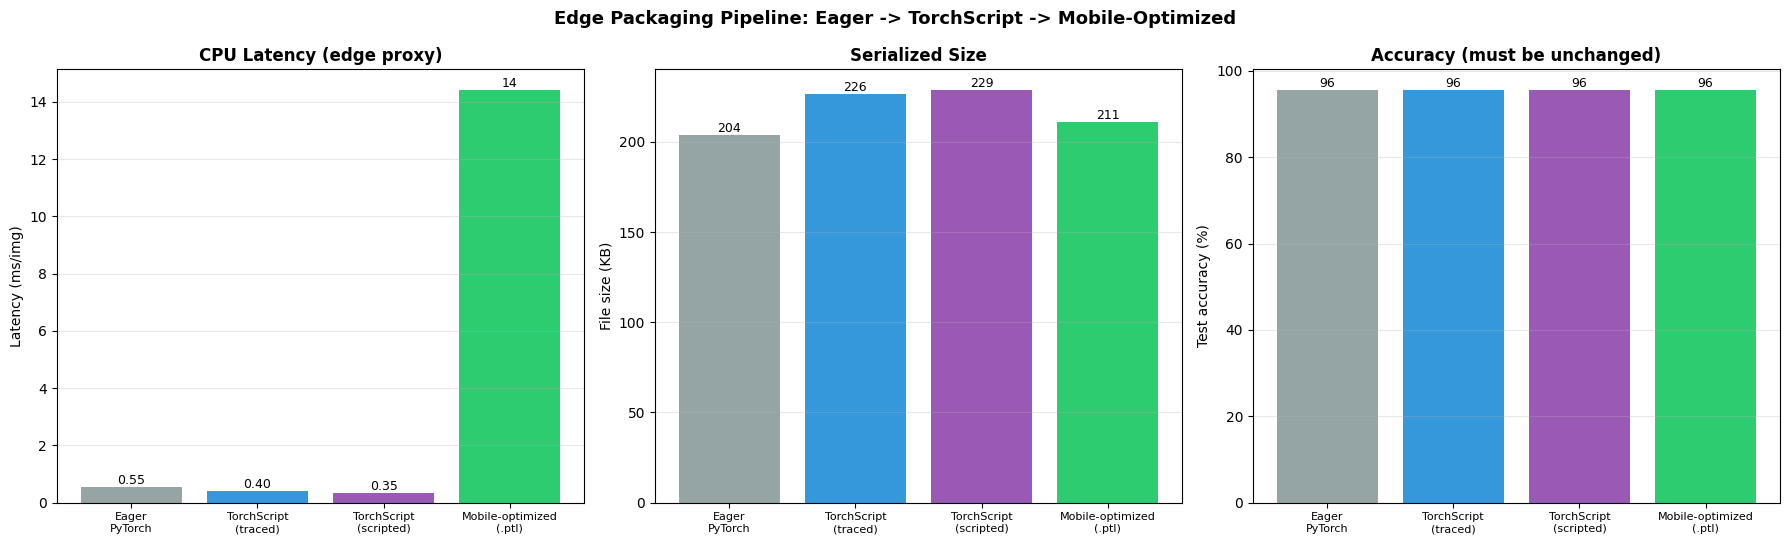

Saved edge_latency_benchmark.png


In [5]:
def bench_ms(fn, x, n_warmup=15, n_runs=300):
    with torch.no_grad():
        for _ in range(n_warmup):
            fn(x)
        times = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            fn(x)
            times.append(time.perf_counter() - t0)
    return np.mean(times) * 1000, times

bench_x = torch.randn(1, 1, 28, 28)
eager_ms,   eager_times   = bench_ms(model, bench_x)
traced_ms,  traced_times  = bench_ms(traced_model, bench_x)
scripted_ms, scripted_times = bench_ms(scripted_model, bench_x)
mobile_ms,  mobile_times  = bench_ms(mobile_model, bench_x)

names   = ['Eager\nPyTorch', 'TorchScript\n(traced)', 'TorchScript\n(scripted)', 'Mobile-optimized\n(.ptl)']
lat_ms  = [eager_ms, traced_ms, scripted_ms, mobile_ms]
sizes_kb = [sum(p.numel()*p.element_size() for p in model.parameters())/1024,
            file_size_kb('tinycnn_traced.pt'), file_size_kb('tinycnn_scripted.pt'), mobile_size]
accs_pct = [eager_acc*100, traced_acc*100, scripted_acc*100, mobile_acc*100]
colors_e = ['#95a5a6', '#3498db', '#9b59b6', '#2ecc71']

for n, l, s, a in zip(names, lat_ms, sizes_kb, accs_pct):
    print(f'{n.replace(chr(10)," "):26s}  latency={l:.4f} ms  size={s:7.1f} KB  acc={a:.2f}%')

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, vals, ylabel, title in zip(
    axes, [lat_ms, sizes_kb, accs_pct],
    ['Latency (ms/img)', 'File size (KB)', 'Test accuracy (%)'],
    ['CPU Latency (edge proxy)', 'Serialized Size', 'Accuracy (must be unchanged)']):
    bars = ax.bar(names, vals, color=colors_e)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v, f'{v:.2f}' if v < 10 else f'{v:.0f}',
                ha='center', va='bottom', fontsize=9)
    ax.set_ylabel(ylabel); ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Edge Packaging Pipeline: Eager -> TorchScript -> Mobile-Optimized', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('edge_latency_benchmark.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved edge_latency_benchmark.png')

## Section 5: What a Full TFLite / NCNN Conversion Would Add

We've demonstrated the hardware-independent half of edge deployment (interpreter removal,
op fusion). A real TFLite or NCNN deployment adds a second half we can't exercise here
without the extra toolchain and (for the final number) the ARM device itself:

| Step | TFLite path | NCNN path | Why we're not running it here |
|------|-------------|-----------|-------------------------------|
| Source format | Needs a TensorFlow/Keras graph, **or** ONNX → TF via `onnx2tf` | Needs ONNX → NCNN via `onnx2ncnn`/`pnnx` | Extra converter packages, not installed; would add tens of MB of TF/protobuf tooling for a CPU sandbox that already has a working ONNX path (Wednesday's notebook) |
| Our ONNX file | `tiny_classifier.onnx` from Wednesday would be the input to `onnx2tf` | Same file would be the input to `onnx2ncnn` | Reuses Wednesday's export — no new export step needed |
| Quantization | TFLite converter has its own INT8 post-training quantizer (`tf.lite.Optimize.DEFAULT`) — separate from PyTorch's | NCNN has `ncnnoptimize` + its own INT8 calibration tool | Different quantization stack per framework — none are interchangeable |
| Kernel dispatch | XNNPACK (CPU) or the GPU/NNAPI/Hexagon **delegate** — ARM-NEON-tuned | Hand-written ARM NEON/Vulkan kernels, no external dependency | This is the part that genuinely needs the target ARM chip to benchmark meaningfully — a CPU (x86) run of these tools would not reflect real device performance |
| Typical binary | `.tflite` FlatBuffer, tens of KB to a few MB | `.param` (text graph) + `.bin` (weights) | — |

**Bottom line:** the packaging/optimization *methodology* transfers directly (that's what
Sections 2-4 proved with real numbers); only the final ARM-NEON-kernel number requires
hardware we don't have in this sandbox. Converting `tiny_classifier.onnx` with `onnx2tf` or
`onnx2ncnn` on a real ARM board would be the natural next step outside this notebook.

## Summary

| Format | Real work done in this notebook | Needs external hardware/tooling for the full picture |
|--------|----------------------------------|---------------------------------------------------------|
| TorchScript (trace) | Exported + benchmarked | No — fully valid on CPU |
| TorchScript (script) | Exported + benchmarked | No — fully valid on CPU |
| PyTorch Mobile (.ptl, mobile-optimized) | Exported + benchmarked, fusion verified in the printed graph | Final ARM NEON kernel numbers need a phone/board |
| TFLite | Conceptual only | Yes — `onnx2tf` + ARM device |
| NCNN | Conceptual only | Yes — `onnx2ncnn`/`pnnx` + ARM device |

### Exercises
1. Add a data-dependent `if` to `TinyCNN.forward` (e.g. skip `conv2` for very dark images) and see `torch.jit.trace` silently produce a graph that ignores it — then fix it with `torch.jit.script`.
2. Convert `tiny_classifier.onnx` from Wednesday's notebook with `onnx2tf` (`pip install onnx2tf`) if you have a machine where the extra TF dependency is acceptable, and compare `.tflite` file size to `tinycnn_mobile.ptl` here.
3. Try `torch.export` + `ExecutorchBackendConfig` (PyTorch's ExecuTorch, the Lite Interpreter's replacement) and compare the workflow.
4. Profile which single op takes the most time in the mobile-optimized graph with `torch.profiler` — is it still Conv, or does the flatten/reshape dominate at this tiny scale?
5. Repeat Section 4's benchmark with a batch size of 8 instead of 1 — does the eager-vs-TorchScript gap change?